In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchmetrics
import helper_utils
helper_utils.set_seed(42)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
class SimpleCNN(nn.Module) :
    def __init__(self) :
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(p=0.4)

    def forward(self, x) :
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def evaluate_accuracy(model, val_loader, device) :
        model.eval()
        total_correct = 0
        total_samples = 0

        with torch.no_grad() :
            for inputs, labels in val_loader :
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total_correct += (predicted == labels).sum().item()
                total_samples += labels.size(0)

        accuracy = total_correct / total_samples
        return accuracy

In [4]:
def train_and_evaluate(learning_rate, device, n_epochs=25, batch_size=128) :
    helper_utils.set_seed(42)
    model = SimpleCNN().to(device)
    loss_fcn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_dataloader, val_dataloader = helper_utils.get_dataset_dataloaders(batch_size=batch_size)
    helper_utils.train_model(model=model, optimizer=optimizer, loss_fcn=loss_fcn, train_dataloader=train_dataloader, device=device, n_epochs=n_epochs) 
    accuracy = evaluate_accuracy(model=model, val_loader=val_dataloader, device=device)
    print(f"Learning Rate : {learning_rate}, Accuracy : {accuracy:.4f}")
    return accuracy

In [5]:
learning_rates = [0.00001, 0.0001, 0.01, 0.1]
accuracies = []

for lr in learning_rates :
    accuracy = train_and_evaluate(learning_rate=lr, device=device)
    accuracies.append(accuracy)

Current Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5 - Train Loss: 2.2588
Epoch 10 - Train Loss: 2.1827
Epoch 15 - Train Loss: 2.1124
Epoch 20 - Train Loss: 2.0539
Epoch 25 - Train Loss: 2.0046
Training complete!

Learning Rate : 1e-05, Accuracy : 0.3195


Current Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/63 [00:00<?, ?it/s]

...

Current Batch:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5 - Train Loss: 1.6867
Epoch 10 - Train Loss: 1.5366
Epoch 15 - Train Loss: 1.4557
Epoch 20 - Train Loss: 1.3786
Epoch 25 - Train Loss: 1.3174
Training complete!

Learning Rate : 0.01, Accuracy : 0.4260


Current Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5 - Train Loss: 2.3073
Epoch 10 - Train Loss: 2.3103
Epoch 15 - Train Loss: 2.3094
Epoch 20 - Train Loss: 2.3066
Epoch 25 - Train Loss: 2.3079
Training complete!

Learning Rate : 0.1, Accuracy : 0.1005


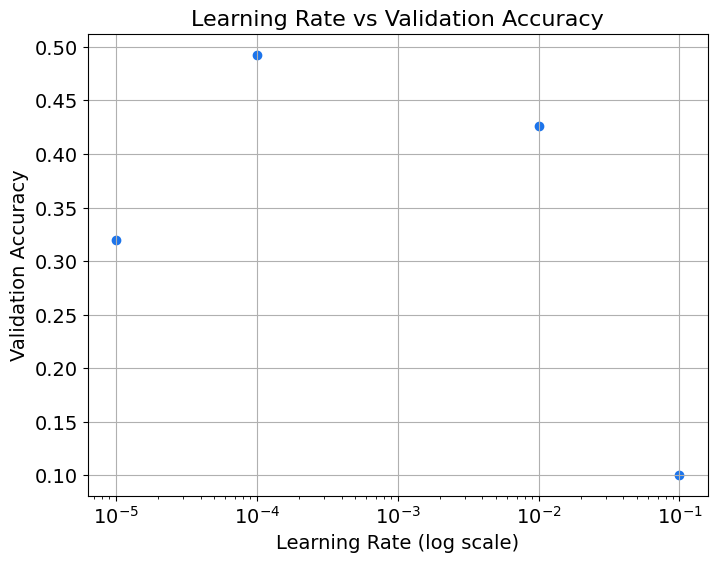

In [6]:
helper_utils.plot_results(learning_rates, accuracies)

In [7]:
def evaluate_metrics(model, val_dataloader, device, num_classes=10) :
    model.eval()
    accuracy_metric = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes, average="macro").to(device)
    precision_metric = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average="macro").to(device)
    recall_metric = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average="macro").to(device)
    f1_metric = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device)

    with torch.no_grad() :
        for inputs, labels in val_dataloader :
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            accuracy_metric.update(predicted, labels)

            precision_metric.update(predicted, labels)
            recall_metric.update(predicted, labels)
            f1_metric.update(predicted, labels)
            
    accuracy = accuracy_metric.compute().item()
    precision = precision_metric.compute().item()
    recall = recall_metric.compute().item()
    f1 = f1_metric.compute().item()

    return accuracy, precision, recall, f1

    

In [8]:
model = SimpleCNN().to(device)
train_dataloader, val_dataloader = helper_utils.get_dataset_dataloaders(batch_size=128)
accuracy, precision, recall, f1 = evaluate_metrics(model=model, val_dataloader=val_dataloader, device=device)
print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Accuracy: 0.1000, Precision: 0.0103, Recall: 0.1000, F1 Score: 0.0187


In [9]:
def train_and_evaluate_metrics(learning_rate, device, n_epochs=25, batch_size=128, imbalanced=False):
    helper_utils.set_seed(42)
    model = SimpleCNN().to(device)
    loss_fcn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_dataloader, val_dataloader = helper_utils.get_dataset_dataloaders(batch_size=batch_size, imbalanced=imbalanced)
    helper_utils.train_model(model=model, optimizer=optimizer, loss_fcn=loss_fcn, train_dataloader=train_dataloader, device=device, n_epochs=n_epochs) 
    accuracy, precision, recall, f1 = evaluate_metrics(model, val_dataloader, device)

    print(
        f"Learning Rate: {learning_rate}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}"
    )
    return accuracy, precision, recall, f1

In [10]:
dict_metrics = []

for lr in learning_rates :
    n_epochs = 25
    batch_size = 128
    accuracy, precision, recall, f1 =  train_and_evaluate_metrics(learning_rate=lr, device=device, n_epochs=n_epochs, batch_size=batch_size)

    metrics_lr = {
        "learning_rate" : lr,
        "accuracy" : accuracy,
        "precision" : precision,
        "recall" : recall, 
        "f1_score" : f1,
    }
    dict_metrics.append(metrics_lr)

df_metrics = pd.DataFrame(dict_metrics)

Current Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5 - Train Loss: 2.2588
Epoch 10 - Train Loss: 2.1827
Epoch 15 - Train Loss: 2.1124
Epoch 20 - Train Loss: 2.0539
Epoch 25 - Train Loss: 2.0046
Training complete!

Learning Rate: 1e-05, Accuracy: 0.3194, Precision: 0.3405, Recall: 0.3194, F1: 0.2827


Current Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/63 [00:00<?, ?it/s]

...

Current Batch:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5 - Train Loss: 1.6867
Epoch 10 - Train Loss: 1.5366
Epoch 15 - Train Loss: 1.4557
Epoch 20 - Train Loss: 1.3786
Epoch 25 - Train Loss: 1.3174
Training complete!

Learning Rate: 0.01, Accuracy: 0.4223, Precision: 0.4224, Recall: 0.4223, F1: 0.4139


Current Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5 - Train Loss: 2.3073
Epoch 10 - Train Loss: 2.3103
Epoch 15 - Train Loss: 2.3094
Epoch 20 - Train Loss: 2.3066
Epoch 25 - Train Loss: 2.3079
Training complete!

Learning Rate: 0.1, Accuracy: 0.1000, Precision: 0.0101, Recall: 0.1000, F1: 0.0183


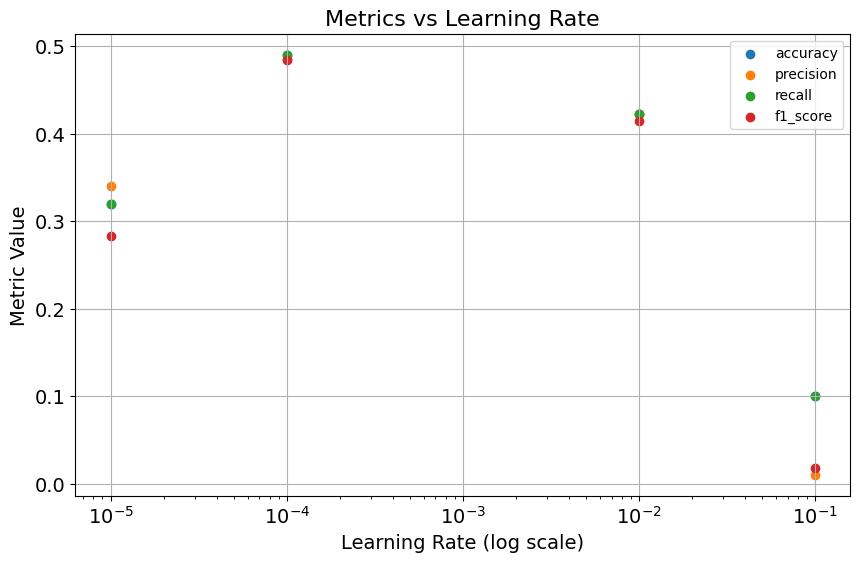

In [11]:
helper_utils.plot_metrics_vs_learning_rate(df_metrics)

In [12]:
dict_metrics = []
batch_sizes = [32, 64, 128]
lr = 0.001  
imbalanced = True
n_epochs = 25

for bs in batch_sizes:
    acc, prec, rec, f1 = train_and_evaluate_metrics(batch_size=bs, n_epochs=n_epochs, learning_rate=lr, device=device, imbalanced=imbalanced)

    metrics_bs = {
        "batch_size": bs,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
    }
    dict_metrics.append(metrics_bs)

df_metrics = pd.DataFrame(dict_metrics)

Current Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/213 [00:00<?, ?it/s]

Epoch 5 - Train Loss: 0.6704
Epoch 10 - Train Loss: 0.5436
Epoch 15 - Train Loss: 0.4406
Epoch 20 - Train Loss: 0.3206
Epoch 25 - Train Loss: 0.2379
Training complete!

Learning Rate: 0.001, Accuracy: 0.6465, Precision: 0.6942, Recall: 0.6465, F1: 0.6663


Current Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 5 - Train Loss: 0.7132
Epoch 10 - Train Loss: 0.6109
Epoch 15 - Train Loss: 0.5224
Epoch 20 - Train Loss: 0.4394
Epoch 25 - Train Loss: 0.3498
Training complete!

Learning Rate: 0.001, Accuracy: 0.6890, Precision: 0.7104, Recall: 0.6890, F1: 0.6987


Current Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Current Batch:   0%|          | 0/54 [00:00<?, ?it/s]

Epoch 5 - Train Loss: 0.7632
Epoch 10 - Train Loss: 0.6489
Epoch 15 - Train Loss: 0.5863
Epoch 20 - Train Loss: 0.5331
Epoch 25 - Train Loss: 0.4765
Training complete!

Learning Rate: 0.001, Accuracy: 0.6725, Precision: 0.7009, Recall: 0.6725, F1: 0.6818


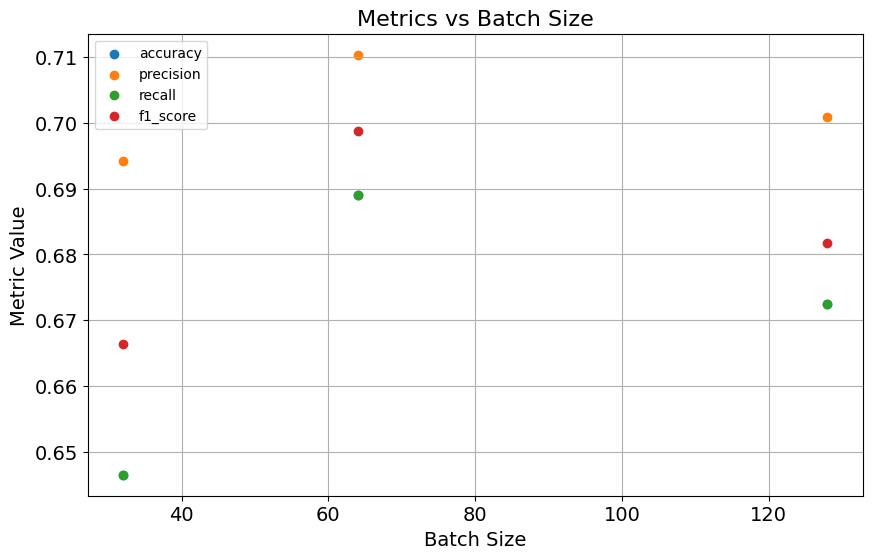

In [13]:
helper_utils.plot_metrics_vs_batch_size(df_metrics)